# EDA of SSVEP signals

## SSVEP signals


Steady-State Visual-Evoekd Potential is a brain resposne by a visual stumulus, flickering at a constant frequency between approximatively 6 an 100 Hz. The resposne manifests itself as an increace in amplitude of the stimulated frequency.

## Data

Based on our project specifications, the MAMEM dataset was selected for Explanatory Data Analysis (EDA). This dataset aligns perfectly with our requirements due to its limited number of classes, as we intend to use 4 to 6 flicking diodes corresponding to specific directional commands (left, right, up, down, straight, and back).

The MAMEM Steady-State Visually Evoked Potentials (SSVEP) database, which contains 256-channel EEG recordings from 11 subjects under flickering light stimulation, has been expanded with a second experimental dataset. During this experiment, subjects were exposed to non-overlapping flickering lights from five magenta boxes operating at frequencies of 6.66 Hz, 7.5 Hz, 8.57 Hz, 10 Hz, and 12 Hz, while 256-channel EEG data was captured.

## Libraries used

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from moabb.datasets import MAMEM3
from moabb.paradigms import SSVEP
from scipy.signal import welch
from sklearn.cross_decomposition import CCA
from scipy.signal import cheby1, filtfilt

/home/user/github/TALON/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = MAMEM3()
paradigm = SSVEP()

Choosing the first None classes from all possible events


Data from first subject

In [4]:
#subjects = dataset.subject_list

X, labels, metadata = paradigm.get_data(
    dataset=dataset,
    subjects=[1]
)

### Basic dataset features

In [5]:
print(X.shape)
print(labels.shape)
print(labels)
print(metadata.head())
print(pd.Series(labels).value_counts())

(125, 14, 385)
(125,)
['7.50' '10.00' '8.57' '6.66' '12.00' '10.00' '6.66' '7.50' '10.00' '8.57'
 '12.00' '6.66' '7.50' '8.57' '10.00' '7.50' '12.00' '10.00' '6.66' '8.57'
 '7.50' '12.00' '8.57' '12.00' '8.57' '7.50' '10.00' '8.57' '6.66' '12.00'
 '10.00' '6.66' '7.50' '10.00' '8.57' '12.00' '6.66' '7.50' '8.57' '10.00'
 '7.50' '12.00' '10.00' '6.66' '8.57' '7.50' '12.00' '8.57' '12.00' '8.57'
 '7.50' '10.00' '8.57' '6.66' '12.00' '10.00' '6.66' '7.50' '10.00' '8.57'
 '12.00' '6.66' '7.50' '8.57' '10.00' '7.50' '12.00' '10.00' '6.66' '8.57'
 '7.50' '12.00' '8.57' '12.00' '8.57' '7.50' '10.00' '8.57' '6.66' '12.00'
 '10.00' '6.66' '7.50' '10.00' '8.57' '12.00' '6.66' '7.50' '8.57' '10.00'
 '7.50' '12.00' '10.00' '6.66' '8.57' '7.50' '12.00' '8.57' '12.00' '8.57'
 '7.50' '10.00' '8.57' '6.66' '12.00' '10.00' '6.66' '7.50' '10.00' '8.57'
 '12.00' '6.66' '7.50' '8.57' '10.00' '7.50' '12.00' '10.00' '6.66' '8.57'
 '7.50' '12.00' '8.57' '12.00' '8.57']
   subject session run
0        1      

As we can see, the trial counts for each frequency are similar, ranging from 20 to 30.

For SSVEP signals, we are most interested in occipital brain signals recorded from channels such as O1, Oz, and O2, as well as parieto-occipital signals from channels like POz, PO3, and PO4.

![Occipital Lobe](assets/Occipital.jpg)

Simple data representations

In this part, I used basic visual representations of the EEG signal to understand its structure before applying classification methods. One of the most important tools was the Welch function, which estimates the Power Spectral Density (PSD) of the signal.

Power Spectral Density shows how the power of the signal is distributed across different frequencies. In the context of SSVEP signals, this is especially important because the brain response should contain stronger activity at the frequency of the visual stimulus, for example 6.66 Hz, and sometimes also at its harmonics, such as 13.32 Hz or 19.98 Hz.

The Welch method works by dividing the signal into shorter overlapping segments, calculating the spectrum for each segment, and then averaging the results. This makes the PSD estimation more stable and less noisy than calculating a single Fourier transform on the whole signal.

https://en.wikipedia.org/wiki/Welch%27s_method

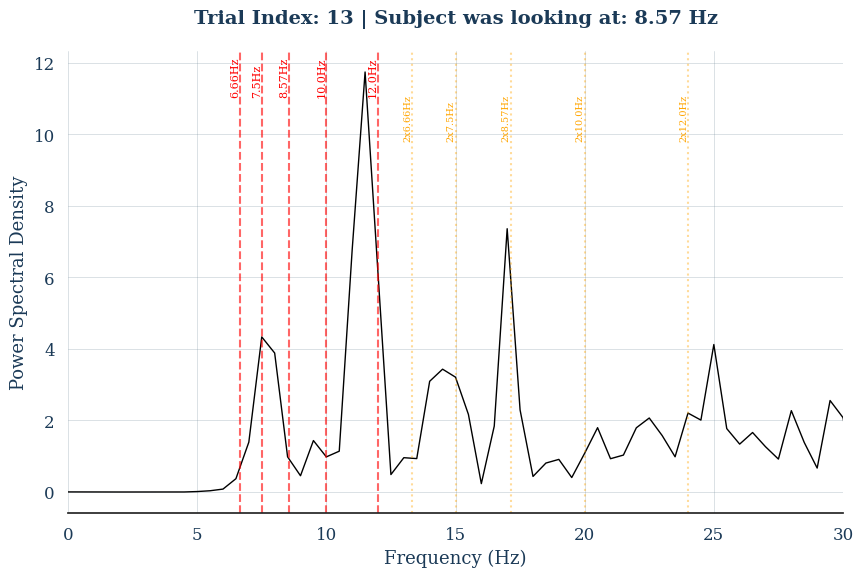

In [6]:
trial_idx = 13 
trial = X[trial_idx]
channel_signal = trial[trial_idx]

current_label = labels[trial_idx]

fs = 128
target_freqs = [6.66, 7.50, 8.57, 10.00, 12.00]

freqs, psd = welch(channel_signal, fs=fs, nperseg=fs*2)

plt.figure(figsize=(10, 6))
plt.plot(freqs, psd, color='black', linewidth=1)

for f in target_freqs:
    plt.axvline(x=f, color='red', linestyle='--', alpha=0.6)
    plt.text(f, plt.ylim()[1]*0.9, f'{f}Hz', rotation=90, color='red', fontsize=8, ha='right')
    
    h2 = f * 2
    if h2 <= 30:
        plt.axvline(x=h2, color='orange', linestyle=':', alpha=0.4)
        plt.text(h2, plt.ylim()[1]*0.8, f'2x{f}Hz', rotation=90, color='orange', fontsize=7, ha='right')

plt.title(f"Trial Index: {trial_idx} | Subject was looking at: {current_label} Hz", 
          fontsize=14, fontweight='bold', pad=20)

plt.xlim(0, 30)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.show()

Despite the application of Welch’s power spectral density (PSD) estimation, the observed frequency components exhibited insufficient alignment with the target stimulus frequencies. The presence of spurious local maxima and the lack of distinct peaks at the expected harmonics suggest a low signal-to-noise ratio (SNR). Consequently, alternative feature extraction methods may be required to isolate the SSVEP response from background cortical activity.To ilustrate this problem I prepared diagram below.

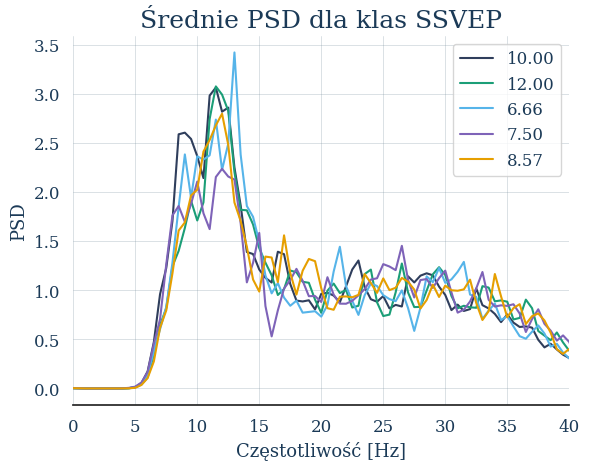

In [7]:

channel_idx = 0

unique_labels = np.unique(labels)

for lab in unique_labels:
    X_lab = X[labels == lab]
    
    psds = []
    for trial in X_lab:
        signal = trial[channel_idx]
        freqs, psd = welch(signal, fs=fs, nperseg=fs*2)
        psds.append(psd)
    
    mean_psd = np.mean(psds, axis=0)
    plt.plot(freqs, mean_psd, label=str(lab))

plt.xlim(0, 40)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("PSD")
plt.title("Średnie PSD dla klas SSVEP")
plt.legend()
plt.show()

As illustrated in plot above the grand average power spectral density (PSD) curves fail to show distinct, class-specific peaks at their respective target stimulation frequencies (6.66 Hz, 7.50 Hz, 8.57 Hz, 10.00 Hz, and 12.00 Hz). Instead, the spectral profiles across all experimental conditions are dominated by a broad, overlapping elevation in power within the 7–14 Hz band. This pronounced morphology is indicative of strong endogenous alpha rhythms, which effectively mask the narrower, stimulus-entrained SSVEP components and yield an insufficient signal-to-noise ratio (SNR) for univariate frequency-domain classification.

To address the limitations of raw spectral decomposition via Welch’s method, a Signal-to-Noise Ratio (SNR) metric was employed to quantify the magnitude of the SSVEP response relative to the baseline noise floor. Following power spectral density (PSD) estimation, the SNR was calculated as the ratio of the spectral power at the target stimulation frequency (ftarget​) to the mean power of the adjacent frequency bins. In the context of SSVEP decoding, this approach provides an objective, normalized index of stimulus-entrained cortical activity, effectively isolating narrow-band evoked responses from broadband background electroencephalographic (EEG) noise and mitigating individual variations in baseline alpha activity.

In [8]:

def get_nearest_freq_idx(freqs: np.ndarray,
                        target_freq: float) -> int:
    """ Returns the index of the nearest frequency bin.
    
    Args:
        freqs (array_like): Array or list of frequency bins (ints or floats).
        target_freq (float): Target frequency to find.
    
    Returns: 
        int: Index of the nearest frequency bin.

    Raises:
        ValueError: If target_freq is negative or if any frequency in freqs is negative.
        ValueError: If the frequency array is empty.
        TypeError: If target_freq is not a number or freqs contains non-numeric types.
    """

    freqs = np.asanyarray(freqs)

    if target_freq < 0 or np.any(freqs < 0):
        raise ValueError("Frequencies must be non-negative.")
    
    if freqs.size == 0:
        raise ValueError("Frequency array cannot be empty.")

    if not np.issubdtype(freqs.dtype, np.number):
        raise ValueError("freqs must contain only integers or floats.")

    return np.argmin(np.abs(freqs - target_freq))


def compute_snr_at_freq(freqs: np.ndarray,
                        psd: np.ndarray,
                        target_freq: float, 
                        noise_width: int = 2, 
                        skip_width: int = 1) -> tuple[float, float]:
    """Computes SNR for a single frequency.

    Args:
        freqs (array_like): Array or list of frequency bins (ints or floats).
        target_freq (float): Target frequency to find.
        psd (array): Power spectral densaity for a single EEG signal. 
        noise_width  (int): Nubmer of bins to take as noise on each side of the target frequency.
        skip_width (int): Number of adjacent bins to skip on each side of the target frequency.

    Returns
        snr (float) : SNR as the ratio of signal power to noise power. 
        snr_db (float) SNR in decibels
    
    """

    if(noise_width < 1 or skip_width < 0):
        raise ValueError("noise_width must be >= 1 and skip_width must be >= 0.")
    
    if len(freqs) != len(psd):
        raise ValueError("Length of freqs and psd must be the same.")
    
    if target_freq < 0:
        raise ValueError("target_freq must be non-negative.")

    idx = get_nearest_freq_idx(freqs, target_freq)

    signal_power = psd[idx]

    left_start = idx - skip_width - noise_width
    left_end = idx - skip_width

    right_start = idx + skip_width + 1
    right_end = idx + skip_width + noise_width + 1

    if left_start < 0 or right_end > len(psd):
        return np.nan, np.nan

    noise_bins = np.concatenate([
        psd[left_start:left_end],
        psd[right_start:right_end]
    ])

    noise_power = np.mean(noise_bins)

    snr = signal_power / noise_power
    snr_db = 10 * np.log10(snr)

    return snr, snr_db

In [10]:
rows = []

for trial_idx, trial in enumerate(X):
    true_label = float(labels[trial_idx])
    trial_result = {"trial": trial_idx, "true_label": true_label}

    channel_psds = []
    for channel_idx in range(trial.shape[0]):
        f_bins, psd_vals = welch(trial[channel_idx], fs=fs, nperseg=trial.shape[1])
        channel_psds.append((f_bins, psd_vals))

    for target_freq in target_freqs:
        snrs_for_channels = []
        snrs_db_for_channels = []

        for f_bins, psd_vals in channel_psds:
            snr, snr_db = compute_snr_at_freq(
                freqs=f_bins,
                psd=psd_vals,
                target_freq=target_freq,
                noise_width=2,
                skip_width=1
            )
            snrs_for_channels.append(snr)
            snrs_db_for_channels.append(snr_db)

        trial_result[f"SNR_{target_freq:.2f}"] = np.nanmean(snrs_for_channels)
        trial_result[f"SNRdB_{target_freq:.2f}"] = np.nanmean(snrs_db_for_channels)

    rows.append(trial_result)

snr_df = pd.DataFrame(rows)

best_col = snr_df[[f"SNR_{f:.2f}" for f in target_freqs]].idxmax(axis=1)
snr_df["predicted_label"] = best_col.str.replace("SNR_", "").astype(float)

snr_df["correct"] = snr_df["true_label"] == snr_df["predicted_label"]


In [11]:
accuracy = snr_df["correct"].mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 44.00%


Although the SNR measures look promising, the classifier still reaches only about 44% accuracy. That is better than random chance (~25%), but still too low for practical use. For that reason, I moved on to a more robust predictor: canonical correlation analysis (CCA), which is a common industry-standard method for SSVEP detection.

In [54]:

def generate_reference_signals(freq, length_sec, fs, n_harmonics=3):
    """Generates sine and cosine reference signals for CCA."""
    t = np.linspace(0, length_sec, int(fs * length_sec), endpoint=False)
    refs = []
    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))
    return np.array(refs) # Shape: (2 * n_harmonics, samples)

## CCA 

In [ ]:
def get_cca_correlation(data : np.ndarray, ref : np.ndarray) -> float:
    """Computes the maximum canonical correlation between EEG data and reference.
    
        Args:
            data: (channels, samples) EEG data for a single trial.
            ref: (n_refs, samples) Reference signals for a specific frequency (including harmonics

        Returns:
            corr: Maximum canonical correlation coefficient.

    """

    X = data.T 
    Y = ref.T
    
    cca = CCA(n_components=1)
    X_c, Y_c = cca.fit_transform(X, Y)
    
    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]
    return corr

def generate_reference_signals(freq: float, length_sec: float, fs: int, n_harmonics: int = 3) -> np.ndarray:
    """Generates sine/cosine reference signals for a given stimulus frequency.

    Args:
        freq (float): Target stimulation frequency in Hz.
        length_sec (float): Trial duration in seconds.
        fs (int): Sampling rate in Hz.
        n_harmonics (int): Number of harmonics to include.

    Returns:
        np.ndarray: Reference signals with shape (2 * n_harmonics, n_samples).
    """
    n_samples = int(fs * length_sec)
    t = np.arange(n_samples) / fs
    refs = []

    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))

    return np.vstack(refs)

In [15]:

length_sec = X.shape[2] / fs

references = {f: generate_reference_signals(f, length_sec, fs) for f in target_freqs}

results = []

for trial_idx, trial in enumerate(X):
    correlations = []
    
    for f in target_freqs:
        ref = references[f]
        rho = get_cca_correlation(trial, ref)
        correlations.append(rho)
    
    predicted_idx = np.argmax(correlations)
    predicted_freq = target_freqs[predicted_idx]
    
    results.append({
        "trial": trial_idx,
        "true_label": labels[trial_idx],
        "predicted_label": predicted_freq
    })

cca_df = pd.DataFrame(results)
cca_df["correct"] = np.isclose(
    cca_df["true_label"].astype(float),
    cca_df["predicted_label"].astype(float),
    atol=0.01
)

print(f"CCA Accuracy: {cca_df['correct'].mean():.2%}")

CCA Accuracy: 65.60%


The implementation of multi-channel Canonical Correlation Analysis (CCA) yielded a classification accuracy of 65.6%. This represents a substantial improvement over the univariate SNR-based predictor (44%), demonstrating that leveraging the spatial distribution of the visual cortex via multivariate analysis significantly enhances feature discriminability.  

However, this performance falls slightly below the conventional 70% accuracy threshold required for practical BCI applications. The standard CCA framework is inherently constrained because it relies on generic, artificial sine-cosine templates that do not capture individual phase delays or temporal variations in the user's electroencephalographic (EEG) profile. Furthermore, standard CCA operates across the entire preprocessed spectrum uniformly, failing to exploit the highly informative harmonic frequencies (2f,3f) of the SSVEP response while remaining susceptible to broadband background noise.